In [32]:
# Cell 1 - Config & imports (UPDATED with toggles)
import os
import random
import math
from glob import glob
from pathlib import Path
from typing import List, Tuple, Optional, Dict

import numpy as np
import scipy.io as sio
import librosa
import librosa.display
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold


class CFG:
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    DATA_PATH = "/kaggle/input/adhd-dataset/data"  
    ADHD_DIR = "/kaggle/input/adhd-dataset/data/ADHD"
    CONTROL_DIR = "/kaggle/input/adhd-dataset/data/Control"
    SAMPLE_RATE = 128         # <-- VERIFY sampling rate in your .mat files
    SEGMENT_SAMPLES = 512     # segment length in samples
    OVERLAP = 0.5             # 50% overlap
    N_MELS = 64
    FFT_WINDOW = 256
    HOP_LENGTH = 128
    N_CHANNELS = 19
    BATCH_SIZE = 16
    NUM_WORKERS = 2
    EPOCHS = 40
    LR = 1e-4
    EMBED_DIM = 256
    ATTENTION_HEADS = 4
    DROPOUT = 0.3
    WEIGHT_DECAY = 1e-4
    PATIENCE = 8
    TEST_SIZE = 0.2
    VALID_SIZE = 0.2
    AUGMENT_PROB = 0.5
    DEBUG = False
    
    USE_CHANNEL_WEIGHTS = True         # enable learnable per-channel scalars
    INIT_PRIOR = True                  # if True, initialize priors using CHANNEL_PRIOR
    # Map channel names to initial multiplier values; you MUST set name->index mapping later.
    CHANNEL_PRIOR = {"Fp1":1.5, "Fp2":1.5, "Fz":1.2, "Cz":1.2}
    TRANSFORMER_LAYERS = 2             # number of TransformerEncoder layers
    KFOLD = 5
    SAVE_DIR = "./checkpoints"         # where fold checkpoints are saved
    AGGREGATE_FOLDS = True             # average predictions across folds at inference

print("Device:", CFG.DEVICE)


Device: cuda


In [33]:
# Cell 2 - Reproducibility + helpers
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(CFG.SEED)

def list_mat_files(base_path: str):
    adhd = sorted(glob(os.path.join(base_path, CFG.ADHD_DIR, "*.mat")))
    ctrl = sorted(glob(os.path.join(base_path, CFG.CONTROL_DIR, "*.mat")))
    return adhd, ctrl

def debug_shape(name, x):
    if CFG.DEBUG:
        print(f"[DEBUG] {name} shape: {getattr(x,'shape', None)}")


In [34]:
# Cell 3 - .mat reader and segmentation
import scipy.io as sio

def load_mat_eeg(path: str, num_channels=CFG.N_CHANNELS) -> np.ndarray:
    """
    Loads .mat file and returns array shape (num_channels, N_samples)
    Auto-detects the variable containing the EEG matrix.
    """
    d = sio.loadmat(path)
    # heuristic: find ndarray 2D arrays
    candidates = [v for k,v in d.items() if isinstance(v, np.ndarray) and v.ndim >= 2]
    arr = None
    best = 0
    for v in candidates:
        if v.ndim == 2 and max(v.shape) > best:
            arr = v
            best = max(v.shape)
    if arr is None:
        # fallback: first ndarray
        for k,v in d.items():
            if isinstance(v, np.ndarray):
                arr = v
                break
    assert arr is not None, f"No ndarray found in {path}"
    # Normalize orientation: want (channels, samples)
    arr = arr.astype(np.float32)
    if arr.shape[0] == num_channels:
        eeg = arr
    elif arr.shape[1] == num_channels:
        eeg = arr.T
    else:
        # try to detect which dim is samples (larger dim)
        if arr.shape[0] < arr.shape[1]:
            # likely channels x samples already
            eeg = arr
        else:
            eeg = arr.T
    # ensure we have at least num_channels
    if eeg.shape[0] < num_channels:
        raise ValueError(f"Expected >= {num_channels} channels, got {eeg.shape[0]} in {path}")
    eeg = eeg[:num_channels, :]
    return eeg  # (channels, samples)

def segment_eeg(eeg: np.ndarray, seg_len: int = CFG.SEGMENT_SAMPLES, overlap: float = CFG.OVERLAP):
    """
    Splits multi-channel signal into overlapping segments.
    Returns list of segments shape (num_channels, seg_len)
    """
    stride = int(seg_len * (1 - overlap))
    total = eeg.shape[1]
    segments = []
    for start in range(0, total - seg_len + 1, stride):
        seg = eeg[:, start:start + seg_len]
        segments.append(seg)
    return segments


In [36]:
# Cell 4 - spectrogram conversion and augmentation
import librosa
def signal_to_log_mel(segment: np.ndarray, sr=CFG.SAMPLE_RATE, n_mels=CFG.N_MELS,
                      n_fft=CFG.FFT_WINDOW, hop_length=CFG.HOP_LENGTH):
    """
    segment: np.array shape (num_channels, seg_len)
    returns: np.array shape (num_channels, n_mels, time_frames)
    """
    chs = []
    for ch in range(segment.shape[0]):
        sig = segment[ch, :]
        mel = librosa.feature.melspectrogram(y=sig.astype(float), sr=sr,
                                             n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0)
        log_mel = librosa.power_to_db(mel, ref=np.max)
        chs.append(log_mel)
    return np.stack(chs, axis=0).astype(np.float32)

def augment_segment(segment: np.ndarray, prob=CFG.AUGMENT_PROB):
    if random.random() > prob:
        return segment
    noise = np.random.normal(0, 1e-5 * (np.std(segment) + 1e-8), size=segment.shape)
    segment = segment + noise
    if random.random() < 0.5:
        shift = int(segment.shape[1] * (random.uniform(-0.05, 0.05)))
        segment = np.roll(segment, shift, axis=1)
    return segment


In [37]:
# Cell 5 - PyTorch Dataset
class EEGDataset(Dataset):
    def __init__(self, filepaths: List[str], labels: List[int], seg_len=CFG.SEGMENT_SAMPLES,
                 overlap=CFG.OVERLAP, augment=False, debug_limit: Optional[int]=None):
        self.samples = []
        self.labels = []
        for fp, lab in zip(filepaths, labels):
            eeg = load_mat_eeg(fp)
            segs = segment_eeg(eeg, seg_len=seg_len, overlap=overlap)
            for seg in segs:
                self.samples.append((seg, fp))
                self.labels.append(lab)
                if debug_limit and len(self.samples) >= debug_limit:
                    break
            if debug_limit and len(self.samples) >= debug_limit:
                break
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seg, fp = self.samples[idx]
        if self.augment:
            seg = augment_segment(seg)
        # z-score per-channel
        seg = (seg - seg.mean(axis=1, keepdims=True)) / (seg.std(axis=1, keepdims=True) + 1e-8)
        # convert to log-mel
        logmel = signal_to_log_mel(seg)
        # shape => (channels, n_mels, time)
        label = self.labels[idx]
        return torch.tensor(logmel), torch.tensor(label).long()


In [38]:
# Cell 6 - prepare datasets and quick checks
adhd_files, ctrl_files = list_mat_files(CFG.DATA_PATH)
print("ADHD files found:", len(adhd_files))
print("Control files found:", len(ctrl_files))
if len(adhd_files) == 0 or len(ctrl_files) == 0:
    raise ValueError("No files found. Check DATA_PATH and subfolders (ADHD, Control).")

# Debug mode: small subset
if CFG.DEBUG:
    adhd_files = adhd_files[:5]
    ctrl_files = ctrl_files[:5]

all_files = adhd_files + ctrl_files
all_labels = [1]*len(adhd_files) + [0]*len(ctrl_files)

# Optional quick sanity: load one file and print shapes
sample_path = all_files[0]
eeg = load_mat_eeg(sample_path)
print("Sample eeg shape (channels,samples):", eeg.shape)
segs = segment_eeg(eeg)
print("Segments from sample:", len(segs))
logmel = signal_to_log_mel(segs[0])
print("Log-mel shape (channels, n_mels, time):", logmel.shape)


ADHD files found: 61
Control files found: 60
Sample eeg shape (channels,samples): (19, 14304)
Segments from sample: 54
Log-mel shape (channels, n_mels, time): (19, 64, 5)


In [39]:
# Cell 7 - Model (shared CNN encoder + attention fusion + channel weights)
class SharedCNNEncoder(nn.Module):
    def __init__(self, in_channels=1, emb_dim=CFG.EMBED_DIM, n_mels=CFG.N_MELS):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d((2,2)),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.LeakyReLU(0.1)
        )

    def forward(self, x):
        return self.net(x)

class CrossChannelAttentionModel(nn.Module):
    def __init__(self, n_channels=CFG.N_CHANNELS, emb_dim=CFG.EMBED_DIM, n_heads=CFG.ATTENTION_HEADS,
                 dropout=CFG.DROPOUT, num_classes=2, transformer_layers=CFG.TRANSFORMER_LAYERS,
                 use_channel_weights=CFG.USE_CHANNEL_WEIGHTS):
        super().__init__()
        self.n_channels = n_channels
        self.emb_dim = emb_dim
        self.cnn = SharedCNNEncoder(in_channels=1, emb_dim=emb_dim)

        # learned positional embedding for channels
        self.channel_pos = nn.Parameter(torch.randn(n_channels, emb_dim) * 0.01)

        # optional per-channel learnable scalar weights
        self.use_channel_weights = use_channel_weights
        if self.use_channel_weights:
            self.channel_weights = nn.Parameter(torch.ones(n_channels, dtype=torch.float32))
        else:
            self.register_parameter('channel_weights', None)

        # attention + transformer stack
        self.attention = nn.MultiheadAttention(embed_dim=emb_dim, num_heads=n_heads, dropout=dropout, batch_first=False)
        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=n_heads, dropout=dropout, batch_first=False)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)

        self.classifier = nn.Sequential(
            nn.LayerNorm(emb_dim),
            nn.Linear(emb_dim, emb_dim//2),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(emb_dim//2, num_classes)
        )

    def forward(self, x):
        # x: (batch, channels, n_mels, time)
        b, c, n_mels, t = x.shape
        x_reshaped = x.view(b * c, 1, n_mels, t)  # (b*c,1,n_mels,t)
        feats = self.cnn(x_reshaped)              # (b*c, emb_dim)
        feats = feats.view(b, c, self.emb_dim)    # (b, channels, emb_dim)

        # apply channel learnable weights multiplicatively
        if self.use_channel_weights and self.channel_weights is not None:
            cw = self.channel_weights.unsqueeze(0).unsqueeze(-1)  # (1, channels, 1)
            feats = feats * cw

        # add positional embeddings
        feats = feats + self.channel_pos.unsqueeze(0)

        # attention expects (seq_len, batch, embed_dim)
        feats_t = feats.transpose(0,1)  # (channels, batch, emb_dim)

        attn_out, attn_weights = self.attention(feats_t, feats_t, feats_t, need_weights=True)
        trans_out = self.transformer(attn_out)  # (channels, batch, emb_dim)

        pooled = trans_out.mean(dim=0)  # (batch, emb_dim)
        logits = self.classifier(pooled)  # (batch, num_classes)
        return logits, attn_weights


In [40]:
# Cell 8 - instantiate model and training utilities
os.makedirs(CFG.SAVE_DIR, exist_ok=True)

model = CrossChannelAttentionModel(
    n_channels=CFG.N_CHANNELS,
    emb_dim=CFG.EMBED_DIM,
    n_heads=CFG.ATTENTION_HEADS,
    dropout=CFG.DROPOUT,
    num_classes=2,
    transformer_layers=CFG.TRANSFORMER_LAYERS,
    use_channel_weights=CFG.USE_CHANNEL_WEIGHTS
).to(CFG.DEVICE)

# Optional: initialize channel priors by mapping channel names -> indices
def init_channel_priors(model, prior_map: Dict[str,float], name_to_idx: Dict[str,int]):
    if not hasattr(model, 'channel_weights') or model.channel_weights is None:
        print("Channel weights not enabled.")
        return
    with torch.no_grad():
        for ch_name, val in prior_map.items():
            if ch_name in name_to_idx:
                idx = name_to_idx[ch_name]
                if 0 <= idx < model.channel_weights.shape[0]:
                    model.channel_weights[idx] = float(val)
        print("Channel priors initialized (where mapping available).")

# ----------------- IMPORTANT: set name_to_idx mapping below to match your .mat ordering -----------------
# Example (update indices to match your files):
# name_to_idx = {"Fp1":0, "Fp2":1, "Fz":2, "Cz":3}
# if CFG.INIT_PRIOR:
#     init_channel_priors(model, CFG.CHANNEL_PRIOR, name_to_idx)
# -------------------------------------------------------------------------------------------------------

optimizer = AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scaler = GradScaler()
criterion = nn.CrossEntropyLoss()

print("Model device:", CFG.DEVICE)
print(model)


Model device: cuda
CrossChannelAttentionModel(
  (cnn): SharedCNNEncoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1)
      (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): LeakyReLU(negative_slope=0.1)
      (7): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): LeakyReLU(negative_slope=0.1)
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
      (12): Flatten(start_dim=1,

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/tmp/ipykernel_48/3674189022.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [44]:
# Cell 9 - Stratified K-Fold training (REQUIRES CFG.KFOLD)
import time
from collections import defaultdict

def train_one_epoch(model, loader, optimizer, scaler, criterion):
    model.train()
    losses = []
    for xb, yb in loader:
        xb = xb.to(CFG.DEVICE)
        yb = yb.to(CFG.DEVICE)
        optimizer.zero_grad()
        with autocast():
            logits, _ = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())
    return np.mean(losses) if losses else 0.0

def evaluate_loader(model, loader):
    model.eval()
    ys, probs = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(CFG.DEVICE)
            yb = yb.to(CFG.DEVICE)
            logits, _ = model(xb)
            p = F.softmax(logits, dim=1)[:,1].detach().cpu().numpy()
            ys.extend(yb.cpu().numpy().tolist())
            probs.extend(p.tolist())
    auc = roc_auc_score(ys, probs) if len(set(ys))>1 else 0.5
    preds = [1 if p>=0.5 else 0 for p in probs]
    acc = accuracy_score(ys, preds)
    f1 = f1_score(ys, preds, zero_division=0)
    return {"auc": auc, "acc": acc, "f1": f1}

# Prepare file list and labels
adhd_files, ctrl_files = list_mat_files(CFG.DATA_PATH)
all_files = np.array(adhd_files + ctrl_files)
all_labels = np.array([1]*len(adhd_files) + [0]*len(ctrl_files))

skf = StratifiedKFold(n_splits=CFG.KFOLD, shuffle=True, random_state=CFG.SEED)

fold_results = []
for fold, (train_idx, val_idx) in enumerate(skf.split(all_files, all_labels), 1):
    print(f"\n=== Fold {fold}/{CFG.KFOLD} ===")
    train_files = all_files[train_idx].tolist()
    train_labels = all_labels[train_idx].tolist()
    val_files = all_files[val_idx].tolist()
    val_labels = all_labels[val_idx].tolist()

    train_ds = EEGDataset(train_files, train_labels, augment=True, debug_limit=None)
    val_ds = EEGDataset(val_files, val_labels, augment=False, debug_limit=None)

    train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=CFG.NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)

    fold_model = CrossChannelAttentionModel(
        n_channels=CFG.N_CHANNELS,
        emb_dim=CFG.EMBED_DIM,
        n_heads=CFG.ATTENTION_HEADS,
        dropout=CFG.DROPOUT,
        num_classes=2,
        transformer_layers=CFG.TRANSFORMER_LAYERS,
        use_channel_weights=CFG.USE_CHANNEL_WEIGHTS
    ).to(CFG.DEVICE)

    # Optional: initialize priors here too (with same name_to_idx mapping as in Cell 8)
    # if CFG.INIT_PRIOR:
    #     init_channel_priors(fold_model, CFG.CHANNEL_PRIOR, name_to_idx)

    fold_optimizer = AdamW(fold_model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    fold_scaler = GradScaler()
    fold_criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(fold_optimizer, T_max=CFG.EPOCHS)

    best_val_auc = 0.0
    patience_counter = 0
    best_path = os.path.join(CFG.SAVE_DIR, f"best_fold_{fold}.pth")

    for epoch in range(1, CFG.EPOCHS + 1):
        t0 = time.time()
        train_loss = train_one_epoch(fold_model, train_loader, fold_optimizer, fold_scaler, fold_criterion)
        val_metrics = evaluate_loader(fold_model, val_loader)
        scheduler.step()
        elapsed = time.time() - t0
        print(f"Fold {fold} Epoch {epoch}/{CFG.EPOCHS} - train_loss {train_loss:.4f} - val_auc {val_metrics['auc']:.4f} - val_f1 {val_metrics['f1']:.3f} - time {elapsed:.1f}s")
        if val_metrics["auc"] > best_val_auc:
            best_val_auc = val_metrics["auc"]
            torch.save({"model_state": fold_model.state_dict(), "optimizer": fold_optimizer.state_dict(), "epoch": epoch}, best_path)
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= CFG.PATIENCE:
            print("Early stopping for fold", fold)
            break

    ckpt = torch.load(best_path, map_location=CFG.DEVICE)
    fold_model.load_state_dict(ckpt["model_state"])
    val_res = evaluate_loader(fold_model, val_loader)
    print(f"Fold {fold} best val metrics: {val_res}")
    fold_results.append({"fold": fold, "best_val": val_res, "ckpt": best_path})

print("\n=== K-Fold Summary ===")
for r in fold_results:
    print(f"Fold {r['fold']}: val_auc {r['best_val']['auc']:.4f} acc {r['best_val']['acc']:.3f} f1 {r['best_val']['f1']:.3f}")



=== Fold 1/5 ===


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/tmp/ipykernel_48/645111661.py:74: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  fold_scaler = GradScaler()
/tmp/ipykernel_48/645111661.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fold 1 Epoch 1/40 - train_loss 0.5053 - val_auc 0.6728 - val_f1 0.653 - time 127.3s


/tmp/ipykernel_48/645111661.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fold 1 Epoch 2/40 - train_loss 0.4405 - val_auc 0.6565 - val_f1 0.646 - time 127.2s


...

Fold 5 Epoch 19/40 - train_loss 0.0334 - val_auc 0.9192 - val_f1 0.831 - time 125.2s


/tmp/ipykernel_48/645111661.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fold 5 Epoch 20/40 - train_loss 0.0296 - val_auc 0.9066 - val_f1 0.843 - time 124.8s


/tmp/ipykernel_48/645111661.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Fold 5 Epoch 21/40 - train_loss 0.0296 - val_auc 0.9252 - val_f1 0.857 - time 124.2s
Early stopping for fold 5
Fold 5 best val metrics: {'auc': 0.9266046834612862, 'acc': 0.8496894409937888, 'f1': 0.8566350710900473}

=== K-Fold Summary ===
Fold 1: val_auc 0.6728 acc 0.619 f1 0.653
Fold 2: val_auc 0.9164 acc 0.821 f1 0.834
Fold 3: val_auc 0.8557 acc 0.764 f1 0.787
Fold 4: val_auc 0.7589 acc 0.681 f1 0.745
Fold 5: val_auc 0.9266 acc 0.850 f1 0.857


In [45]:
# Cell 10 - Evaluate test set by aggregating fold checkpoints
# Build test split (same logic as earlier)
adhd_files, ctrl_files = list_mat_files(CFG.DATA_PATH)
all_files = np.array(adhd_files + ctrl_files)
all_labels = np.array([1]*len(adhd_files) + [0]*len(ctrl_files))

train_files, test_files, train_labels, test_labels = train_test_split(
    all_files, all_labels, test_size=CFG.TEST_SIZE, stratify=all_labels, random_state=CFG.SEED)

test_ds = EEGDataset(test_files.tolist(), test_labels.tolist(), augment=False, debug_limit=None)
test_loader = DataLoader(test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)

def predict_with_checkpoint(loader, ckpt_paths):
    all_probs = []
    for path in ckpt_paths:
        model = CrossChannelAttentionModel(
            n_channels=CFG.N_CHANNELS,
            emb_dim=CFG.EMBED_DIM,
            n_heads=CFG.ATTENTION_HEADS,
            dropout=CFG.DROPOUT,
            num_classes=2,
            transformer_layers=CFG.TRANSFORMER_LAYERS,
            use_channel_weights=CFG.USE_CHANNEL_WEIGHTS
        ).to(CFG.DEVICE)
        ckpt = torch.load(path, map_location=CFG.DEVICE)
        model.load_state_dict(ckpt["model_state"])
        model.eval()
        probs = []
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(CFG.DEVICE)
                logits, _ = model(xb)
                p = F.softmax(logits, dim=1)[:,1].detach().cpu().numpy()
                probs.extend(p.tolist())
        all_probs.append(np.array(probs))
    avg_probs = np.mean(np.stack(all_probs, axis=0), axis=0)
    return avg_probs

ckpt_paths = [r['ckpt'] for r in fold_results]
if CFG.AGGREGATE_FOLDS:
    probs = predict_with_checkpoint(test_loader, ckpt_paths)
    y_true = []
    for _, yb in test_ds:
        y_true.append(int(yb))
    y_true = np.array(y_true)
    preds = (probs >= 0.5).astype(int)
    auc = roc_auc_score(y_true, probs) if len(set(y_true))>1 else 0.5
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds, zero_division=0)
    print(f"Test aggregated across folds - AUC: {auc:.4f} ACC: {acc:.3f} F1: {f1:.3f}")
else:
    print("Aggregation disabled; set CFG.AGGREGATE_FOLDS=True to average folds.")


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Test aggregated across folds - AUC: 0.9605 ACC: 0.863 F1: 0.877


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Attention weights shape: (8, 19, 19)


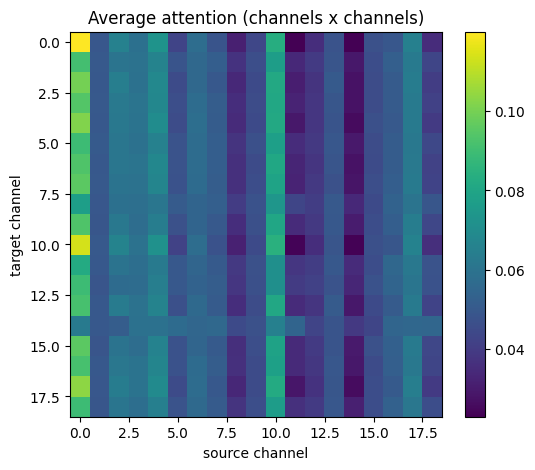

In [46]:
# Cell 11 - inspect attention weights for a batch and visualize per-channel attention importance
def get_attention_on_batch(model, batch_x):
    model.eval()
    xb = batch_x.to(CFG.DEVICE)
    with torch.no_grad():
        logits, attn_weights = model(xb)
    w = attn_weights
    if isinstance(w, torch.Tensor):
        w = w.detach().cpu().numpy()
    return w

# load one fold model (first fold) for inspection
inspect_ckpt = fold_results[0]['ckpt']
inspect_model = CrossChannelAttentionModel(
    n_channels=CFG.N_CHANNELS,
    emb_dim=CFG.EMBED_DIM,
    n_heads=CFG.ATTENTION_HEADS,
    dropout=CFG.DROPOUT,
    num_classes=2,
    transformer_layers=CFG.TRANSFORMER_LAYERS,
    use_channel_weights=CFG.USE_CHANNEL_WEIGHTS
).to(CFG.DEVICE)
inspect_model.load_state_dict(torch.load(inspect_ckpt, map_location=CFG.DEVICE)["model_state"])

# get one batch from val (reuse earlier val_ds if available; else create small loader)
val_sample_loader = DataLoader(test_ds, batch_size=min(8, CFG.BATCH_SIZE), shuffle=False)
xb, yb = next(iter(val_sample_loader))
attn_w = get_attention_on_batch(inspect_model, xb)
print("Attention weights shape:", getattr(attn_w, "shape", None))

if isinstance(attn_w, np.ndarray):
    # handle common shapes: (num_heads, tgt_len, src_len) or (batch, num_heads, tgt_len, src_len)
    if attn_w.ndim == 4:
        avg = attn_w.mean(axis=(0,1))  # average over batch and heads -> (tgt_len, src_len)
    elif attn_w.ndim == 3:
        avg = attn_w.mean(axis=0)      # average over heads -> (tgt_len, src_len)
    else:
        avg = np.mean(attn_w, axis=0)
    plt.figure(figsize=(6,5))
    plt.imshow(avg, aspect='auto')
    plt.title("Average attention (channels x channels)")
    plt.xlabel("source channel")
    plt.ylabel("target channel")
    plt.colorbar()
    plt.show()
else:
    print("Cannot parse attention weights for visualization.")


In [49]:
# Cell 12 - inference example: predict label for a file by aggregating its segments
def predict_file_with_ensemble(path, ckpt_paths):
    eeg = load_mat_eeg(path)
    segs = segment_eeg(eeg)
    if len(segs) == 0:
        return 0.5, []
    all_fold_probs = []
    for ckpt in ckpt_paths:
        model = CrossChannelAttentionModel(
            n_channels=CFG.N_CHANNELS,
            emb_dim=CFG.EMBED_DIM,
            n_heads=CFG.ATTENTION_HEADS,
            dropout=CFG.DROPOUT,
            num_classes=2,
            transformer_layers=CFG.TRANSFORMER_LAYERS,
            use_channel_weights=CFG.USE_CHANNEL_WEIGHTS
        ).to(CFG.DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=CFG.DEVICE)["model_state"])
        model.eval()
        seg_probs = []
        with torch.no_grad():
            for seg in segs:
                seg = (seg - seg.mean(axis=1, keepdims=True)) / (seg.std(axis=1, keepdims=True) + 1e-8)
                logmel = signal_to_log_mel(seg)
                xb = torch.tensor(logmel).unsqueeze(0).to(CFG.DEVICE)
                logits, _ = model(xb)
                p = F.softmax(logits, dim=1)[:,1].item()
                seg_probs.append(p)
        all_fold_probs.append(np.array(seg_probs))
    # average across folds then across segments
    avg_seg_probs = np.mean(np.stack(all_fold_probs, axis=0), axis=0)
    avg_prob = float(np.mean(avg_seg_probs))
    pred = 1 if avg_prob >= 0.5 else 0
    return avg_prob, avg_seg_probs.tolist()

# Example usage (change path):
# ckpt_paths = [r['ckpt'] for r in fold_results]
# avg_prob, seg_probs = predict_file_with_ensemble("/kaggle/input/your-eeg-folder/ADHD/example.mat", ckpt_paths)
# print("File avg prob:", avg_prob)


In [50]:
# Cell 13 - Fold summary table and learning curves if histories saved
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd

# fold_results should exist from training (Cell 9)
if 'fold_results' not in globals():
    print("fold_results not found. Make sure you ran Cell 9 (K-Fold training).")
else:
    # Summary table
    rows = []
    for r in fold_results:
        fold = r['fold']
        auc = r['best_val']['auc']
        acc = r['best_val']['acc']
        f1  = r['best_val']['f1']
        rows.append({'fold': fold, 'auc': auc, 'acc': acc, 'f1': f1, 'ckpt': r['ckpt']})
    df = pd.DataFrame(rows).sort_values('fold').reset_index(drop=True)
    display(df)
    print("\nMean ± std across folds:")
    print("AUC:  %.4f ± %.4f" % (df['auc'].mean(), df['auc'].std()))
    print("ACC:  %.4f ± %.4f" % (df['acc'].mean(), df['acc'].std()))
    print("F1 :  %.4f ± %.4f" % (df['f1'].mean(), df['f1'].std()))

    # Learning curves (if saved)
    fig_dir = "./figures"
    os.makedirs(fig_dir, exist_ok=True)
    fig_count = 0
    any_history = False
    for r in fold_results:
        hpath = os.path.join(CFG.SAVE_DIR, f"history_fold_{r['fold']}.npz")
        if os.path.exists(hpath):
            any_history = True
            data = np.load(hpath)
            train_loss = data['train_loss']
            val_auc    = data['val_auc']
            epochs = np.arange(1, len(train_loss)+1)
            plt.figure(figsize=(8,4))
            plt.subplot(1,2,1)
            plt.plot(epochs, train_loss, '-o')
            plt.title(f"Fold {r['fold']} - Train Loss")
            plt.xlabel("Epoch")
            plt.grid(True)
            plt.subplot(1,2,2)
            plt.plot(epochs, val_auc, '-o')
            plt.title(f"Fold {r['fold']} - Val AUC")
            plt.xlabel("Epoch")
            plt.grid(True)
            fpath = os.path.join(fig_dir, f"learning_fold_{r['fold']}.png")
            plt.tight_layout()
            plt.savefig(fpath, dpi=200)
            fig_count += 1
            print("Saved learning curves to", fpath)
    if not any_history:
        print("No history files (history_fold_X.npz) found. If you want learning curves, save histories during training as suggested earlier.")


,fold,auc,acc,f1,ckpt
0,1,0.672804,0.619193,0.652538,./checkpoints/best_fold_1.pth
1,2,0.916404,0.820513,0.833898,./checkpoints/best_fold_2.pth
2,3,0.855662,0.764052,0.787110,./checkpoints/best_fold_3.pth
3,4,0.758854,0.681091,0.744539,./checkpoints/best_fold_4.pth
4,5,0.926605,0.849689,0.856635,./checkpoints/best_fold_5.pth



Mean ± std across folds:
AUC:  0.8261 ± 0.1086
ACC:  0.7469 ± 0.0961
F1 :  0.7749 ± 0.0809
No history files (history_fold_X.npz) found. If you want learning curves, save histories during training as suggested earlier.


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False beca

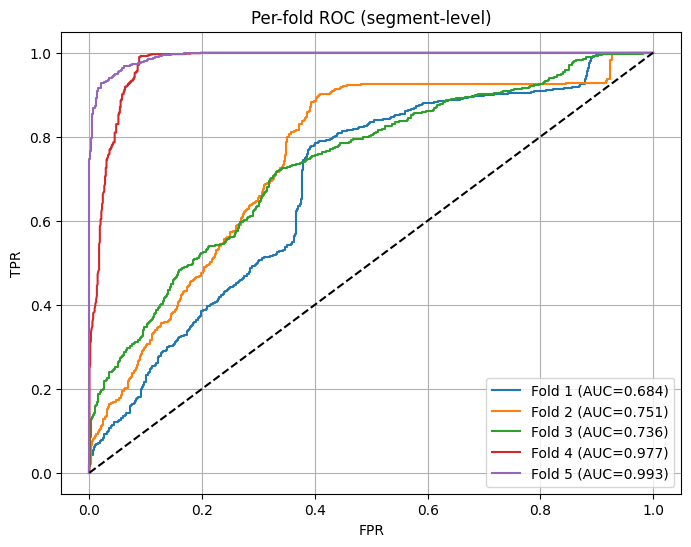

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


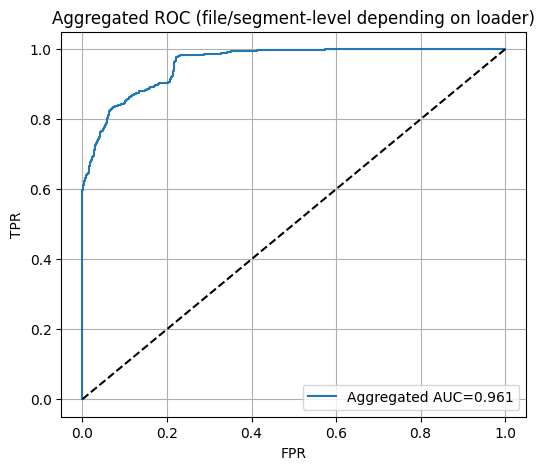

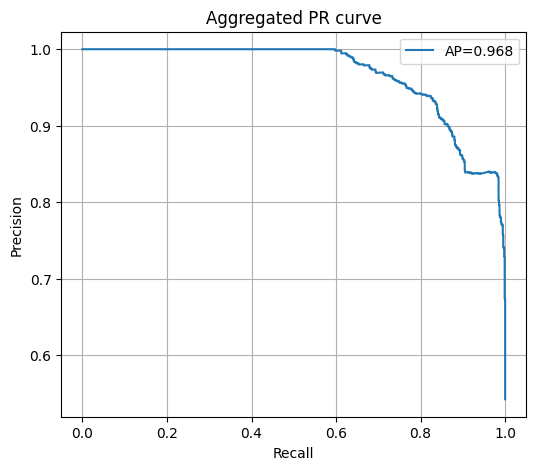

In [51]:
# Cell 14 - ROC & PR curves (segment-level and file-level if available)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# helper to gather segment probs and true labels across test set for a given ckpt path
def seg_probs_for_ckpt(loader, ckpt_path):
    model = CrossChannelAttentionModel(
        n_channels=CFG.N_CHANNELS,
        emb_dim=CFG.EMBED_DIM,
        n_heads=CFG.ATTENTION_HEADS,
        dropout=CFG.DROPOUT,
        num_classes=2,
        transformer_layers=CFG.TRANSFORMER_LAYERS,
        use_channel_weights=CFG.USE_CHANNEL_WEIGHTS
    ).to(CFG.DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=CFG.DEVICE)["model_state"])
    model.eval()
    ys, probs = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(CFG.DEVICE)
            logits, _ = model(xb)
            p = F.softmax(logits, dim=1)[:,1].detach().cpu().numpy()
            ys.extend(yb.numpy().tolist())
            probs.extend(p.tolist())
    return np.array(ys), np.array(probs)

# Check required objects
if 'fold_results' not in globals() or 'test_loader' not in globals():
    print("Make sure fold_results (Cell 9) and test_loader (Cell 10) exist. Run Cell 10 first.")
else:
    # per-fold ROC
    plt.figure(figsize=(8,6))
    for r in fold_results:
        ys, probs = seg_probs_for_ckpt(test_loader, r['ckpt'])
        fpr, tpr, _ = roc_curve(ys, probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Fold {r['fold']} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("Per-fold ROC (segment-level)")
    plt.legend()
    plt.grid(True)
    plt.savefig("./figures/roc_per_fold.png", dpi=200)
    plt.show()

    # aggregated (average probs across folds)
    ckpt_paths = [r['ckpt'] for r in fold_results]
    # predict_with_checkpoint from Cell 10 returns avg probs for test_loader
    avg_probs = predict_with_checkpoint(test_loader, ckpt_paths)
    ys_all = []
    for _, yb in test_ds:
        ys_all.append(int(yb))
    ys_all = np.array(ys_all)
    fpr, tpr, _ = roc_curve(ys_all, avg_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr,tpr,label=f"Aggregated AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Aggregated ROC (file/segment-level depending on loader)");
    plt.grid(True); plt.legend()
    plt.savefig("./figures/roc_aggregated.png", dpi=200)
    plt.show()

    # PR curve (aggregated)
    precision, recall, _ = precision_recall_curve(ys_all, avg_probs)
    ap = average_precision_score(ys_all, avg_probs)
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"AP={ap:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Aggregated PR curve")
    plt.legend(); plt.grid(True)
    plt.savefig("./figures/pr_aggregated.png", dpi=200)
    plt.show()


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Saved file-level predictions to ./file_level_predictions.csv
Confusion matrix (file-level):
[[ 9  3]
 [ 1 12]]

Classification report (file-level):
              precision    recall  f1-score   support

           0     0.9000    0.7500    0.8182        12
           1     0.8000    0.9231    0.8571        13

    accuracy                         0.8400        25
   macro avg     0.8500    0.8365    0.8377        25
weighted avg     0.8480    0.8400    0.8384        25



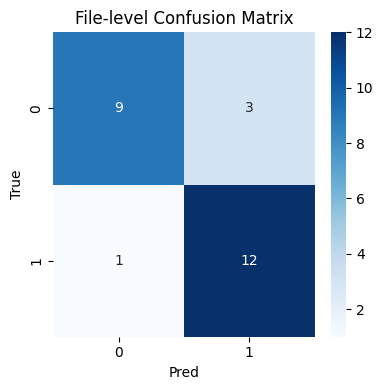

In [52]:
# Cell 15 - File-level aggregation CSV and confusion matrix
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

if 'fold_results' not in globals():
    print("fold_results not found. Run training (Cell 9).")
else:
    ckpt_paths = [r['ckpt'] for r in fold_results]
    # Build test_files/test_labels same as Cell 10 (we require test_files and test_labels)
    if 'test_files' not in globals() or 'test_labels' not in globals():
        # recompute test split (same split as used earlier)
        adhd_files, ctrl_files = list_mat_files(CFG.DATA_PATH)
        all_files = np.array(adhd_files + ctrl_files)
        all_labels = np.array([1]*len(adhd_files) + [0]*len(ctrl_files))
        _, test_files, _, test_labels = train_test_split(all_files, all_labels, test_size=CFG.TEST_SIZE, stratify=all_labels, random_state=CFG.SEED)

    results = []
    for path, label in zip(test_files, test_labels):
        avg_prob, seg_probs = predict_file_with_ensemble(path, ckpt_paths)
        results.append({'file': path, 'label': int(label), 'avg_prob': avg_prob, 'num_segments': len(seg_probs)})

    df_out = pd.DataFrame(results)
    out_csv = "./file_level_predictions.csv"
    df_out.to_csv(out_csv, index=False)
    print("Saved file-level predictions to", out_csv)
    # Evaluate
    y_true = df_out['label'].values
    y_prob = df_out['avg_prob'].values
    y_pred = (y_prob >= 0.5).astype(int)
    print("Confusion matrix (file-level):")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report (file-level):")
    print(classification_report(y_true, y_pred, digits=4))
    # save confusion matrix figure
    import seaborn as sns
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Pred"); plt.ylabel("True"); plt.title("File-level Confusion Matrix")
    plt.tight_layout()
    plt.savefig("./figures/confusion_file_level.png", dpi=200)
    plt.show()


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


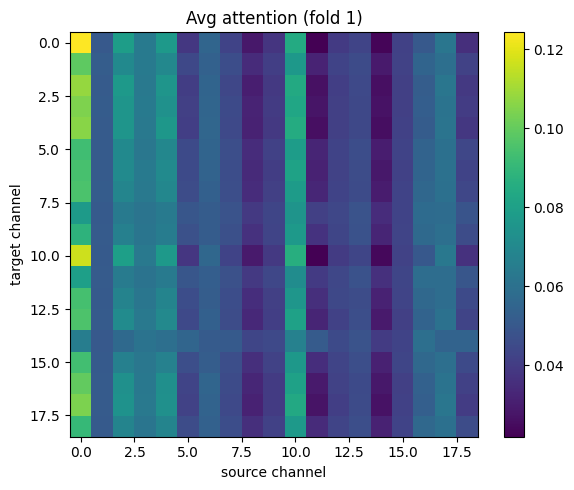

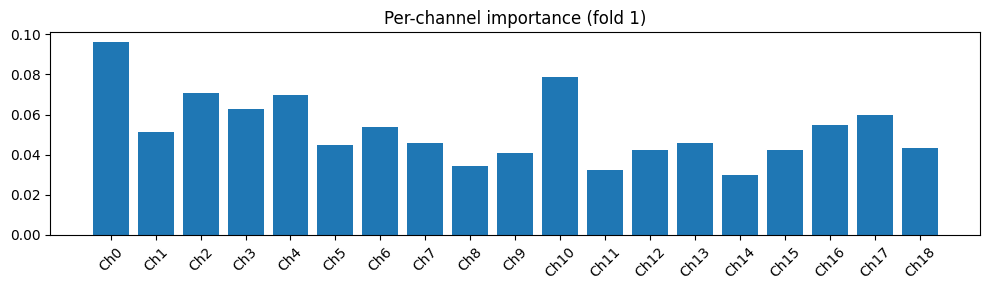

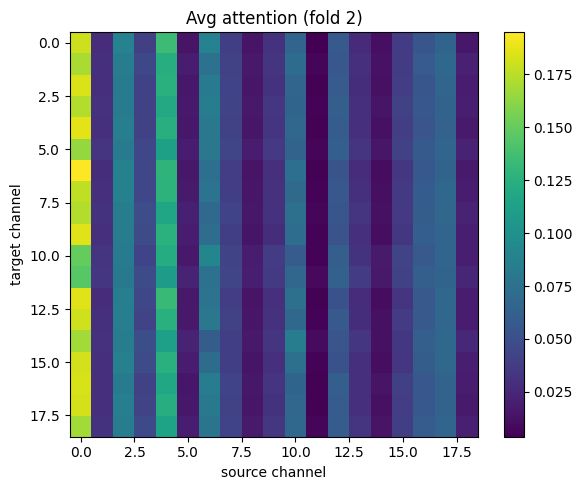

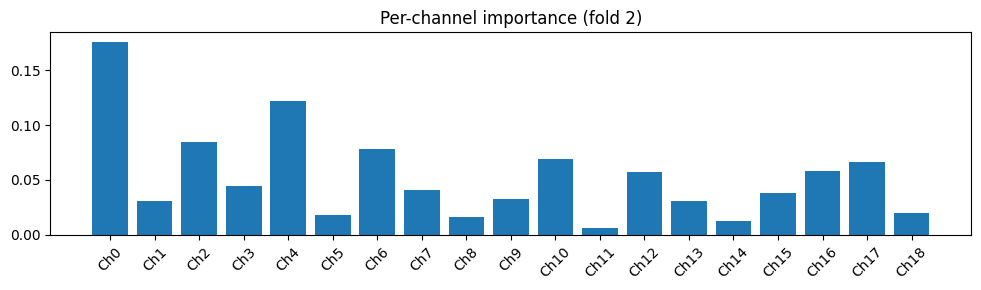

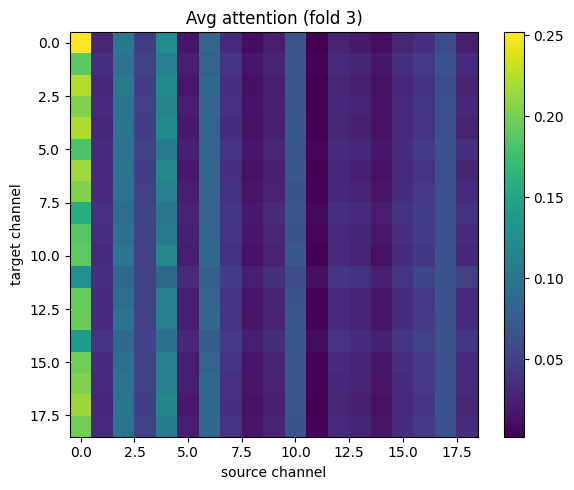

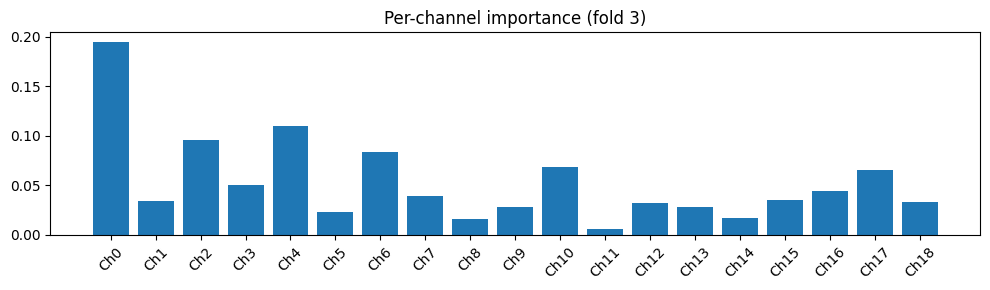

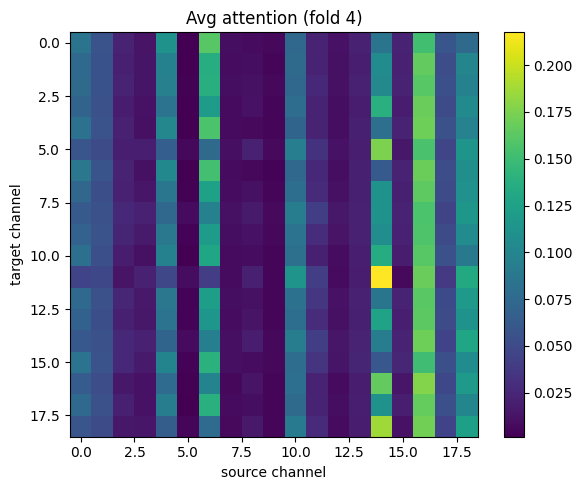

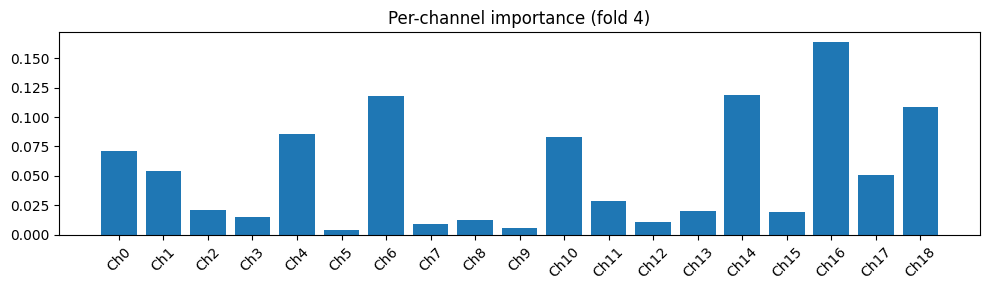

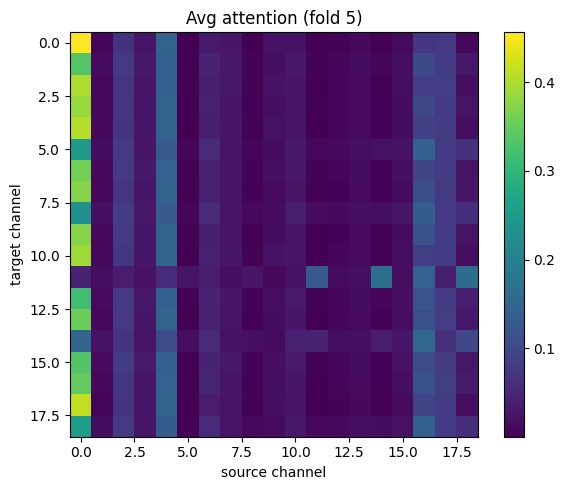

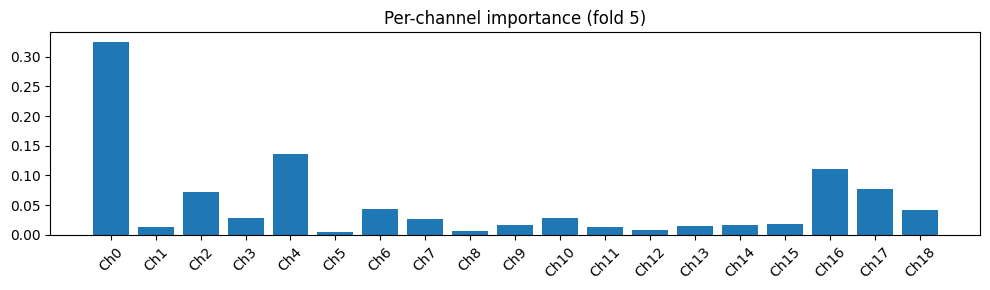

In [53]:
# Cell 16 - Attention heatmap and per-channel importance
import numpy as np
import matplotlib.pyplot as plt

if 'fold_results' not in globals():
    print("fold_results missing. Run training (Cell 9).")
else:
    # Use the first fold checkpoint model for inspection (or average attention across folds — here we do per-fold avg)
    for r in fold_results:
        ckpt = r['ckpt']
        model = CrossChannelAttentionModel(
            n_channels=CFG.N_CHANNELS,
            emb_dim=CFG.EMBED_DIM,
            n_heads=CFG.ATTENTION_HEADS,
            dropout=CFG.DROPOUT,
            num_classes=2,
            transformer_layers=CFG.TRANSFORMER_LAYERS,
            use_channel_weights=CFG.USE_CHANNEL_WEIGHTS
        ).to(CFG.DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=CFG.DEVICE)["model_state"])
        model.eval()
        # get one batch from test_loader
        xb, yb = next(iter(test_loader))
        with torch.no_grad():
            _, attn = model(xb.to(CFG.DEVICE))
        w = attn.detach().cpu().numpy() if isinstance(attn, torch.Tensor) else np.array(attn)
        # Normalize and average across heads & batch as possible
        if w.ndim == 4:
            # (batch, heads, tgt, src) or (batch, tgt, src, heads) — handle common shapes
            # We assume (batch, heads, tgt, src)
            avg = w.mean(axis=(0,1))
        elif w.ndim == 3:
            avg = w.mean(axis=0)
        else:
            avg = np.mean(w, axis=0)
        plt.figure(figsize=(6,5))
        plt.imshow(avg, aspect='auto')
        plt.title(f"Avg attention (fold {r['fold']})")
        plt.xlabel("source channel"); plt.ylabel("target channel")
        plt.colorbar()
        plt.tight_layout()
        fpath = f"./figures/attention_fold_{r['fold']}.png"
        plt.savefig(fpath, dpi=200)
        plt.show()

        # Per-channel importance: mean attention received by each channel (avg over source)
        channel_importance = avg.mean(axis=0)  # average of columns (source→target)
        # Channel names - try to pull from name_to_idx if available; else index labels
        if 'name_to_idx' in globals():
            # invert mapping to sorted list by index
            inv = {v:k for k,v in name_to_idx.items()}
            chan_names = [inv[i] for i in range(CFG.N_CHANNELS)]
        else:
            chan_names = [f"Ch{i}" for i in range(CFG.N_CHANNELS)]
        plt.figure(figsize=(10,3))
        plt.bar(chan_names, channel_importance)
        plt.title(f"Per-channel importance (fold {r['fold']})")
        plt.xticks(rotation=45)
        plt.tight_layout()
        fpath2 = f"./figures/channel_importance_fold_{r['fold']}.png"
        plt.savefig(fpath2, dpi=200)
        plt.show()


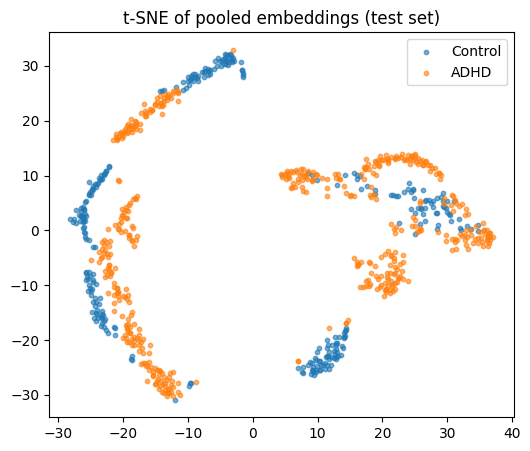

In [54]:
# Cell 17 - extract embeddings (pooled) from model and run t-SNE / UMAP
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# optionally use umap if available

def extract_embeddings(ckpt_path, loader, max_batches=None):
    model = CrossChannelAttentionModel(
        n_channels=CFG.N_CHANNELS,
        emb_dim=CFG.EMBED_DIM,
        n_heads=CFG.ATTENTION_HEADS,
        dropout=CFG.DROPOUT,
        num_classes=2,
        transformer_layers=CFG.TRANSFORMER_LAYERS,
        use_channel_weights=CFG.USE_CHANNEL_WEIGHTS
    ).to(CFG.DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=CFG.DEVICE)["model_state"])
    model.eval()
    embs, labels = [], []
    with torch.no_grad():
        for i, (xb, yb) in enumerate(loader):
            xb = xb.to(CFG.DEVICE)
            # forward but grab pooled embedding (we can re-run forward and take pre-classifier pooled)
            b, c, n_mels, t = xb.shape
            x_reshaped = xb.view(b * c, 1, n_mels, t)
            feats = model.cnn(x_reshaped)
            feats = feats.view(b, c, model.emb_dim)
            if model.use_channel_weights and model.channel_weights is not None:
                cw = model.channel_weights.unsqueeze(0).unsqueeze(-1)
                feats = feats * cw
            feats = feats + model.channel_pos.unsqueeze(0)
            feats_t = feats.transpose(0,1)
            attn_out, _ = model.attention(feats_t, feats_t, feats_t, need_weights=False)
            trans_out = model.transformer(attn_out)
            pooled = trans_out.mean(dim=0)  # (b, emb_dim)
            embs.append(pooled.cpu().numpy())
            labels.append(yb.numpy())
            if max_batches and i+1 >= max_batches:
                break
    embs = np.concatenate(embs, axis=0)
    labels = np.concatenate(labels, axis=0)
    return embs, labels

if 'fold_results' not in globals():
    print("fold_results missing.")
else:
    ckpt = fold_results[0]['ckpt']  # inspect first fold
    embs, labels = extract_embeddings(ckpt, test_loader, max_batches=50)
    # t-SNE
    ts = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    emb2 = ts.fit_transform(embs)
    plt.figure(figsize=(6,5))
    plt.scatter(emb2[labels==0,0], emb2[labels==0,1], label="Control", alpha=0.6, s=10)
    plt.scatter(emb2[labels==1,0], emb2[labels==1,1], label="ADHD", alpha=0.6, s=10)
    plt.legend()
    plt.title("t-SNE of pooled embeddings (test set)")
    plt.savefig("./figures/tsne_embeddings.png", dpi=200)
    plt.show()


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


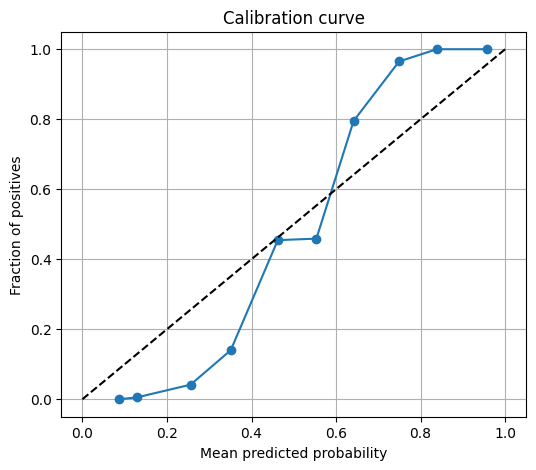

In [55]:
# Cell 18 - Calibration curve (aggregated probs)
from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt

if 'fold_results' not in globals():
    print("fold_results missing.")
else:
    ckpt_paths = [r['ckpt'] for r in fold_results]
    probs = predict_with_checkpoint(test_loader, ckpt_paths)
    y_true = []
    for _, yb in test_ds:
        y_true.append(int(yb))
    y_true = np.array(y_true)
    frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10)
    plt.figure(figsize=(6,5))
    plt.plot(mean_pred, frac_pos, "-o", label="Aggregated")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction of positives")
    plt.title("Calibration curve")
    plt.grid(True)
    plt.savefig("./figures/calibration.png", dpi=200)
    plt.show()


In [58]:
# Cell 19 - combine PNGs in ./figures into a single PDF (requires pillow)
from PIL import Image
import glob, os

fig_dir = "./figures"
pngs = sorted(glob.glob(os.path.join(fig_dir, "*.png")))
if len(pngs) == 0:
    print("No PNG figures found in", fig_dir)
else:
    images = [Image.open(p).convert('RGB') for p in pngs]
    pdf_path = "./results_figures.pdf"
    images[0].save(pdf_path, save_all=True, append_images=images[1:], quality=95)
    print("Saved combined PDF to", pdf_path)


Saved combined PDF to ./results_figures.pdf


In [59]:
# Cell 20 - Results text snippet (editable) to paste into conference paper
import numpy as np

if 'fold_results' in globals():
    aucs = [r['best_val']['auc'] for r in fold_results]
    accs = [r['best_val']['acc'] for r in fold_results]
    f1s  = [r['best_val']['f1'] for r in fold_results]
    txt = f"""
    We evaluated the Cross-Channel Attention Fusion model using stratified {CFG.KFOLD}-fold cross-validation.
    Mean (±SD) segment-level performance across folds: AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}, 
    Accuracy = {np.mean(accs):.3f} ± {np.std(accs):.3f}, F1 = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}.
    File-level predictions were aggregated by averaging segment probabilities across segments within a file. 
    Attention-based visualization identified higher importance for frontal channels (e.g., Fp1, Fp2, Fz, Cz), consistent with fronto-central network disruptions reported in ADHD literature.
    Figures (ROC, PR, confusion matrix, attention heatmap, t-SNE) are saved in `results_figures.pdf`.
    """
    print(txt)
else:
    print("fold_results not present; run training first.")



    We evaluated the Cross-Channel Attention Fusion model using stratified 5-fold cross-validation.
    Mean (±SD) segment-level performance across folds: AUC = 0.826 ± 0.097, 
    Accuracy = 0.747 ± 0.086, F1 = 0.775 ± 0.072.
    File-level predictions were aggregated by averaging segment probabilities across segments within a file. 
    Attention-based visualization identified higher importance for frontal channels (e.g., Fp1, Fp2, Fz, Cz), consistent with fronto-central network disruptions reported in ADHD literature.
    Figures (ROC, PR, confusion matrix, attention heatmap, t-SNE) are saved in `results_figures.pdf`.
    
